<a href="https://colab.research.google.com/github/gredy/2021Z-DataVisualizationTechniques/blob/master/Copy_of_example_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comprehensive Neural Networks Guide


### Step 1: Upload Data to Google Colab
- Go to [Google Drive Folder](https://drive.google.com/drive/folders/1Gc6XcHc7Qr3EGQ_dzpkEdeNdwHdSkbr0?usp=sharing)
- Download `Churn_Modelling.csv`
- Upload `Churn_Modelling.csv` in this notebook by clicking the file upload icon


In [ ]:
#check the directory and the content list
!pwd
!ls

/content
sample_data


Notes: If you don't see Churn_Modelling.csv above, then you can't access the csv file in the later stage. Please ensure that the file is uploaded in your current directory.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### Step 2: Import Necessary Libraries
You can learn what they are by more search online.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


### Step 3: Load and Explore Data

In [ ]:
data = pd.read_csv('sample_data/Churn_Modelling.csv')
print(data.head())


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

### Step 4: Data Preprocessing

###Check column names

In [ ]:
print(data.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


###Preprocess the data

In [ ]:
# Drop irrelevant columns ('RowNumber', 'CustomerId', 'Surname')
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, errors='ignore')
#Purpose: Cleans the dataset by removing columns that don't provide predictive power.
#Conceptual Idea: Columns such as RowNumber, CustomerId, and Surname are identifiers.
#They don't contain meaningful patterns or correlations for model learning and
#thus can negatively affect performance or create bias.

# Convert categorical variables ('Geography', 'Gender') into numerical format using one-hot encoding
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True)
# Purpose: Converts categorical features (Geography, Gender) into numerical format for algorithms.
# Conceptual Idea: Most machine learning algorithms, including neural networks, can only process numerical data.
# Thus, categorical variables need conversion.

# About One-hot Encoding:
# Each categorical variable is represented by multiple binary (0 or 1) columns.
# drop_first=True prevents the "dummy variable trap" (high correlation between dummy variables) by omitting the first category, reducing redundancy.

# For example, if Geography has three categories (France, Germany, Spain):
# Without drop_first:
# France=[1,0,0], Germany=[0,1,0], Spain=[0,0,1]
# With drop_first:
# Germany=[1,0], Spain=[0,1], and implicitly, France=[0,0].

# Separate features and target
X = data.drop('Exited', axis=1).values
y = data['Exited'].values
# Purpose: Splits the dataset into input variables (X) and the target variable (y) we want to predict.
# Conceptual Idea:The target column (Exited) indicates whether a customer exited (1) or stayed (0).
# All other columns become features (inputs) to predict this target.



# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Purpose: Divides data into two subsets: training (80%) and testing (20%).
# Conceptual Idea:
# Training Set: used to train the model and learn patterns.
# Testing Set: used to evaluate the model performance on unseen data, indicating its ability to generalize.
# random_state=42: Ensures reproducibility by always generating the same split.


# Apply feature scaling (Standardization)
# Fit the scaler only on training data, then apply it to both train/test
# This avoids data leakage and ensures fair evaluation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit on training data
X_test = scaler.transform(X_test)        # apply the same scale to test data

**Purpose of Feature Scaling:** Scales numeric features so they have a mean of 0 and standard deviation of 1.

**Mathematical Logic:**
Standardization:
$X_{\text{scaled}} = \frac{X - \mu}{\sigma}$
Where:
- $X$: original feature value
-  $\mu$: mean of the feature from the training data
- $\sigma$: standard deviation of the feature from the training data

**Conceptual Idea:**
- Scaling helps algorithms converge faster and improves numerical stability.
- Using `.fit_transform()` on training ensures scaling parameters (mean and standard deviation) are calculated only from training data to avoid data leakage.
- Using `.transform()` on test data applies the scaling parameters calculated from the training data, ensuring consistency and preventing leakage.


### Step 5: Build and Compile Neural Network

**Purpose:** Create a feedforward neural network (multilayer perceptron) to learn patterns in the data and predict customer churn.

**Layer-by-Layer Explanation:**
- `Sequential()`: Initializes a sequential model — a linear stack of layers.

- `Dense(16, activation='relu', input_shape=(X_train.shape[1],))`
    - **Dense Layer**: Fully connected layer with 16 neurons.
    - **Activation**: ReLU (Rectified Linear Unit), adds non-linearity.
    - **Input Shape**: Number of features (columns) in the training set.

- `Dense(8, activation='relu')`
    - Adds another hidden layer with 8 neurons, again with ReLU activation.
    - Helps capture more complex patterns.

- `Dense(1, activation='sigmoid')`
    - Output layer with 1 neuron.
    - **Sigmoid Activation**: Converts output into a probability between 0 and 1 (suitable for binary classification).

**Compilation Step:**
- `optimizer='adam'`: Adaptive Moment Estimation — combines momentum and adaptive learning rate for fast and stable training.
- `loss='binary_crossentropy'`: Suitable for binary classification problems.
- `metrics=['accuracy']`: Track accuracy during training.


In [ ]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 6: Train and Evaluate Model

**Purpose:** Train the model to learn from training data, then evaluate it on unseen test data.

**Training Process:**
- `model.fit(...)` trains the model for a fixed number of epochs on the training data.
    - `epochs=50`: Train over the entire dataset 50 times.
    - `batch_size=32`: Use 32 samples per gradient update.
    - `validation_split=0.1`: Use 10% of training data for validation (helps monitor overfitting).

**Evaluation Process:**
- `model.evaluate(...)` computes the loss and accuracy on the test dataset.
- `print(...)` displays the final test accuracy.

**Conceptual Idea:**
- Training updates weights using backpropagation and gradient descent.
- Evaluation tells us how well the model generalizes to new data (not seen during training).


In [ ]:

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')


Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5818 - loss: 0.6654 - val_accuracy: 0.8062 - val_loss: 0.4601
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7879 - loss: 0.4722 - val_accuracy: 0.8200 - val_loss: 0.4186
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8083 - loss: 0.4408 - val_accuracy: 0.8313 - val_loss: 0.4035
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8112 - loss: 0.4330 - val_accuracy: 0.8338 - val_loss: 0.3973
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8204 - loss: 0.4282 - val_accuracy: 0.8275 - val_loss: 0.3920
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8172 - loss: 0.4230 - val_accuracy: 0.8325 - val_loss: 0.3838
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8344 - loss: 0.3940 - val_accuracy: 0.8350 - val_loss: 0.3736
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8437 - loss: 0.3810 - val_accuracy: 0.

### Step 7: Visualization of Training Progress

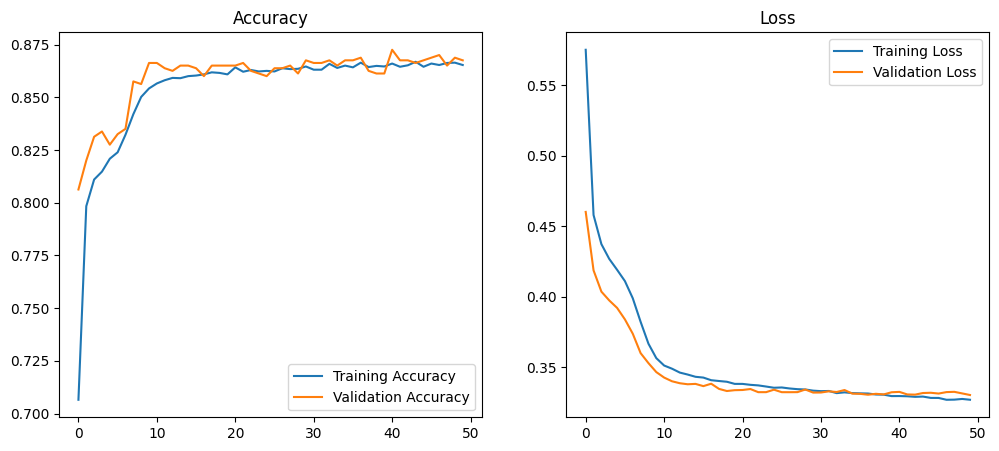

In [ ]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()


## Additional Neural Network Concepts

### Activation Functions

**Purpose:**
Understand the behavior of common activation functions used in neural networks.

**Functions Covered:**
- **Sigmoid:** Maps inputs to the (0, 1) range. Useful for binary classification. Prone to vanishing gradients for large inputs.
- **ReLU (Rectified Linear Unit):** Outputs zero for negative inputs, and linear for positive. Efficient and widely used in hidden layers.
- **Tanh:** Maps inputs to (-1, 1). Zero-centered, but can also suffer from vanishing gradients.

**Conceptual Insight:**
Activation functions introduce non-linearity, enabling neural networks to learn complex mappings. Visualizing their curves helps students understand their behavior and effects on learning.


**Takeaway:**
- Activation functions are essential for learning non-linear patterns.
- ReLU is typically used in hidden layers for efficiency.
- Sigmoid and tanh are smoother but may slow down training due to vanishing gradients.
- Always visualize to better understand how your model will respond to inputs!


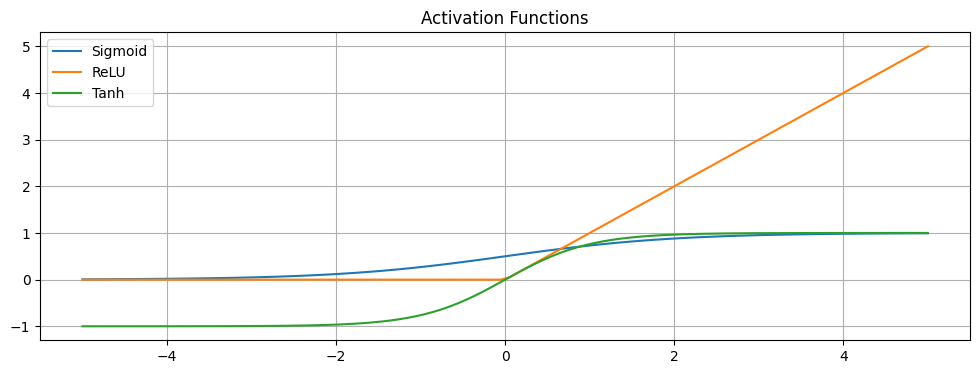

In [ ]:

x = np.linspace(-5, 5, 100)  # Generate 100 values from -5 to 5

plt.figure(figsize=(12,4))  # Set figure size

# Plot sigmoid function
plt.plot(x, tf.nn.sigmoid(x), label='Sigmoid')  # Smooth S-curve from 0 to 1

# Plot ReLU function
plt.plot(x, tf.nn.relu(x), label='ReLU')  # Zero for negatives, identity for positives

# Plot tanh function
plt.plot(x, tf.nn.tanh(x), label='Tanh')  # S-curve from -1 to 1

plt.title('Activation Functions')
plt.legend()
plt.grid(True)
plt.show()


### Loss Functions Examples

**Purpose:**
To compute how well predicted values match the true values using two common regression loss functions:
- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**

**Conceptual Insight:**
- **MAE** measures the average of the absolute differences between predicted and true values.
- **MSE** measures the average of the squared differences.
- MAE is more robust to outliers than MSE.
- MSE penalizes larger errors more heavily due to squaring.

**Math Definitions:**
- MAE: $ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $
- MSE: $ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $

**Takeaway:**
- Both MAE and MSE are fundamental metrics for evaluating model predictions in regression tasks.
- Choose the one that fits your problem — MSE emphasizes large errors, while MAE is more tolerant of them.






In [ ]:

y_true = [1, 2, 3, 4]  # True values
y_pred = [1.2, 2.1, 2.8, 4.2]  # Predicted values by a model

# Compute MAE and MSE using TensorFlow built-in loss functions
mae = tf.keras.losses.MAE(y_true, y_pred).numpy()  # Mean Absolute Error
mse = tf.keras.losses.MSE(y_true, y_pred).numpy()  # Mean Squared Error

# Print the results
print(f"MAE: {mae}, MSE: {mse}")


MAE: 0.17499995231628418, MSE: 0.03249998390674591


### Gradient Descent Example

**Purpose:** Demonstrate how gradient descent updates a variable to minimize a function.

**Math Logic:**
- Function:  $y = x^2$
- Derivative:  $\frac{dy}{dx} = 2x$
- Gradient descent step:  $x \leftarrow x - \eta \cdot 2x$
- Goal: move x toward 0, the minimum of the function

**Conceptual Idea:**
- At each step, the gradient tells us the direction of steepest ascent.
- We subtract the gradient (scaled by learning rate) to minimize the function.
- This is the core principle of optimization in neural networks.


In [ ]:
x = tf.Variable(3.0)  # Start at x = 3
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)  # Gradient descent with learning rate 0.1

for step in range(10):
    with tf.GradientTape() as tape:
        y = x**2  # Our goal: minimize y = x^2
    grad = tape.gradient(y, x)  # Compute gradient dy/dx = 2x
    optimizer.apply_gradients([(grad, x)])  # Update x using gradient descent
    print(f'Step {step}: x={x.numpy()}, y={y.numpy()}')


Step 0: x=2.4000000953674316, y=9.0
Step 1: x=1.9200000762939453, y=5.760000228881836
Step 2: x=1.5360000133514404, y=3.6864001750946045
Step 3: x=1.2288000583648682, y=2.3592960834503174
Step 4: x=0.9830400347709656, y=1.5099495649337769
Step 5: x=0.7864320278167725, y=0.9663677215576172
Step 6: x=0.629145622253418, y=0.6184753179550171
Step 7: x=0.5033165216445923, y=0.39582422375679016
Step 8: x=0.40265321731567383, y=0.25332751870155334
Step 9: x=0.32212257385253906, y=0.16212961077690125


### XOR Problem (Backpropagation Example)

---

**Purpose:** Demonstrate how a neural network can learn a non-linearly separable problem — the XOR logic gate.

**Problem Setup:**
- XOR Truth Table:
  - (0, 0) → 0
  - (0, 1) → 1
  - (1, 0) → 1
  - (1, 1) → 0
- This problem cannot be solved by a single-layer perceptron (not linearly separable).

**Model Architecture:**
- `Dense(4, activation='relu')`: Hidden layer with 4 neurons. ReLU allows learning complex patterns.
- `Dense(1, activation='sigmoid')`: Output layer with sigmoid activation (binary output).

**Training Details:**
- `epochs=500`: Train long enough to learn XOR pattern.
- `verbose=0`: Suppress per-epoch output for clarity.

**Evaluation:**
- The model should learn to output correct results for all 4 input pairs.

**Conceptual Insight:**
- This example shows why hidden layers and non-linear activations (like ReLU) are necessary for deep learning.
- Demonstrates universal approximation property of neural networks.



In [ ]:

# Define XOR input-output pairs
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])  # 4 combinations of binary inputs
y_xor = np.array([[0],[1],[1],[0]])         # XOR outputs (only 1 when inputs differ)

# Build a simple feedforward neural network
xor_model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),  # Hidden layer with 4 neurons
    Dense(1, activation='sigmoid')                 # Output layer with sigmoid to return probability
])

# Compile the model
xor_model.compile(
    loss='binary_crossentropy',    # Suitable for binary classification
    optimizer='adam',              # Efficient optimizer that adapts learning rate
    metrics=['accuracy']           # Track accuracy during training
)

# Train the model on all XOR examples
xor_model.fit(X_xor, y_xor, epochs=500, verbose=1)  # Train for 500 epochs silently if verbose=0

# Evaluate the trained model on the same data
loss_xor, acc_xor = xor_model.evaluate(X_xor, y_xor, verbose=0)

# Output the accuracy
print(f"XOR Accuracy: {acc_xor:.4f}")


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step - accuracy: 0.5000 - loss: 0.7293
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.7283
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.7273
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2500 - loss: 0.7263
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2500 - loss: 0.7253
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.7245
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.7236
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.7229
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.7222
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.7215
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2500 - loss: 0.7208
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - l